Arquivos extraídos em: datasets/casos2
   Arquivo  Passos mínimos até 'S'  Células visitadas  Tempo (s)
0  c2a.txt                      50                385   0.000501
1  c2b.txt                      57               1508   0.001499
2  c2c.txt                      94               5868   0.006500
3  c2e.txt                     154              13433   0.014541
4  c2f.txt                     229              23776   0.026002
5  c2g.txt                     200              36105   0.038499
6  c2h.txt                     377              78671   0.086001


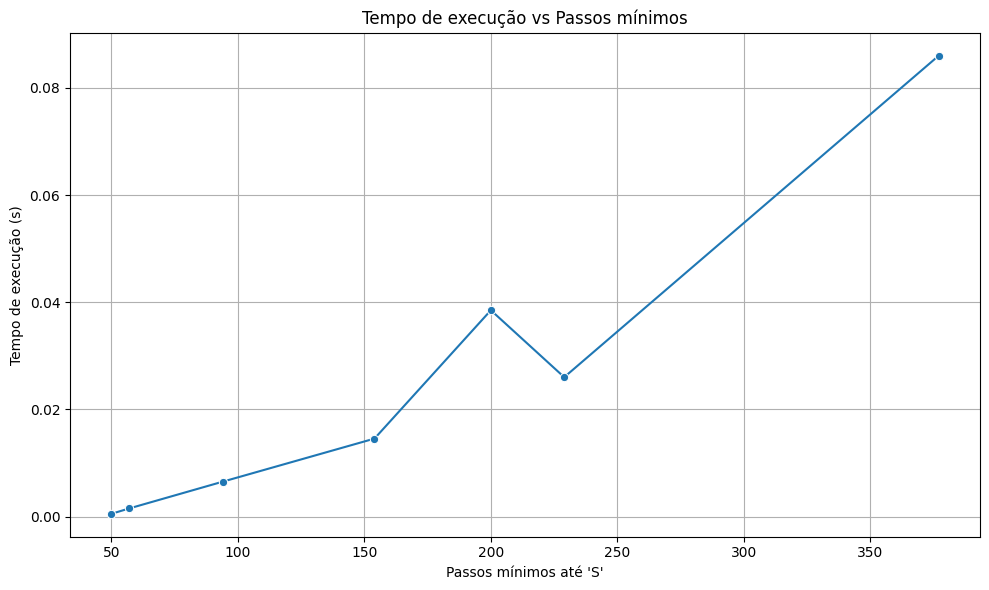

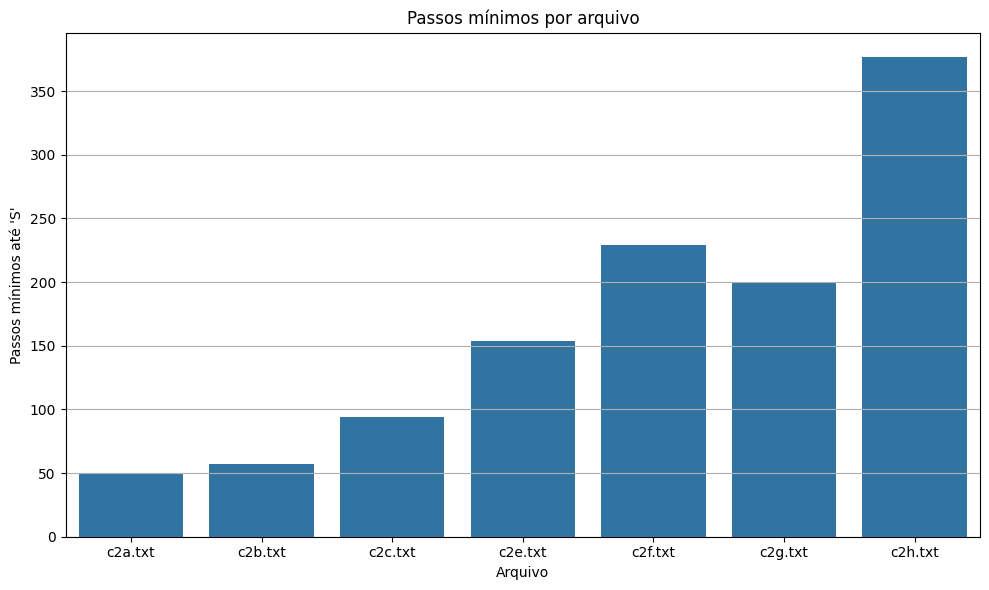

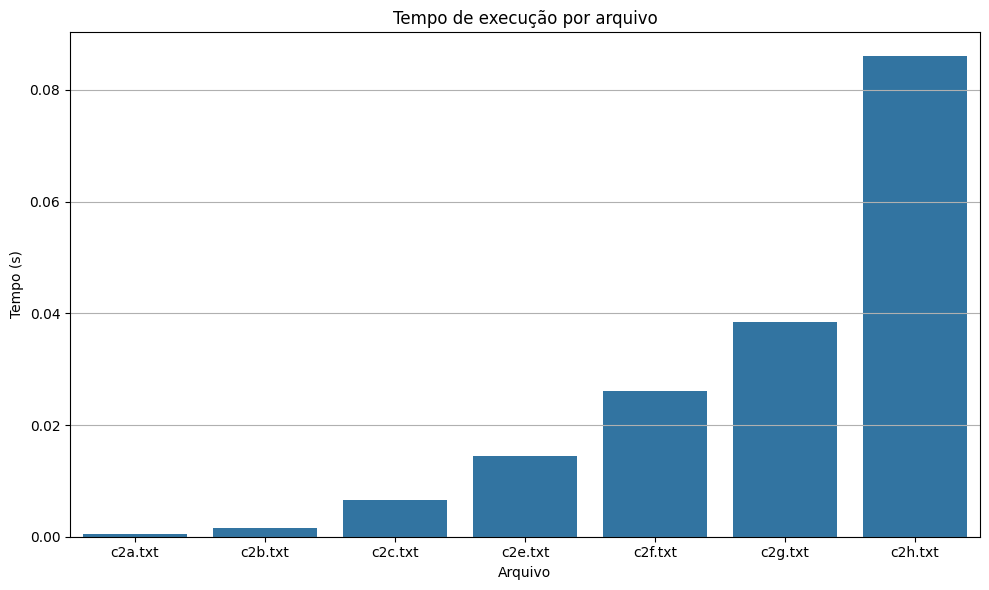

In [4]:
import os
import tarfile
from collections import deque
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho para o arquivo .tar e pasta de extração
caminho_tar = "datasets/casos2.tar"  # Substitua pelo seu caminho correto
pasta_destino = "datasets/casos2"

# Extrai o .tar se ainda não estiver extraído
if not os.path.isdir(pasta_destino):
    with tarfile.open(caminho_tar) as tar:
        tar.extractall(path=pasta_destino)
    print(f"Arquivos extraídos em: {pasta_destino}")

# Direções possíveis (8 vizinhos)
direcoes = [(-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)]

def movimento_valido_reverso(atual, vizinho):
    return ord(atual) - ord(vizinho) <= 1

def bfs_reverso(grid, finais, rows, cols):
    visitado = [[False] * cols for _ in range(rows)]
    fila = deque()
    visitados_total = 0

    for x, y in finais:
        fila.append((x, y, 0))  # linha, coluna, passos
        visitado[x][y] = True
        visitados_total += 1

    menor_caminho = float('inf')

    while fila:
        i, j, passos = fila.popleft()
        atual = grid[i][j]

        if atual == 'a':
            menor_caminho = min(menor_caminho, passos)
            continue

        for dx, dy in direcoes:
            ni, nj = i + dx, j + dy
            if 0 <= ni < rows and 0 <= nj < cols and not visitado[ni][nj]:
                vizinho = grid[ni][nj]
                if movimento_valido_reverso(atual, vizinho):
                    visitado[ni][nj] = True
                    fila.append((ni, nj, passos + 1))
                    visitados_total += 1

    return (menor_caminho if menor_caminho != float('inf') else -1), visitados_total

def ler_mapa_reverso(caminho_arquivo):
    with open(caminho_arquivo, "r") as f:
        raw_lines = f.readlines()

    first_line = raw_lines[0].strip().split()
    rows, cols = map(int, first_line)

    grid = []
    finais = []

    for i in range(1, rows + 1):
        line = raw_lines[i].strip()
        row = list(line)
        for j, char in enumerate(row):
            if char == 'S':
                row[j] = 'a'
            if row[j] == 'z':
                finais.append((i - 1, j))
        grid.append(row)

    return grid, finais, rows, cols

def executar_em_lote(pasta):
    resultados = []

    for nome_arquivo in sorted(os.listdir(pasta)):
        if nome_arquivo.endswith(".txt"):
            caminho = os.path.join(pasta, nome_arquivo)
            grid, finais, rows, cols = ler_mapa_reverso(caminho)

            inicio = time.time()
            passos, visitados = bfs_reverso(grid, finais, rows, cols)
            fim = time.time()

            resultados.append({
                "Arquivo": nome_arquivo,
                "Passos mínimos até 'S'": passos,
                "Células visitadas": visitados,
                "Tempo (s)": round(fim - inicio, 6)
            })

    return pd.DataFrame(resultados)

def gerar_graficos(df):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Passos mínimos até 'S'", y="Tempo (s)", marker='o')
    plt.title("Tempo de execução vs Passos mínimos")
    plt.xlabel("Passos mínimos até 'S'")
    plt.ylabel("Tempo de execução (s)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="Arquivo", y="Passos mínimos até 'S'")
    plt.title("Passos mínimos por arquivo")
    plt.ylabel("Passos mínimos até 'S'")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="Arquivo", y="Tempo (s)")
    plt.title("Tempo de execução por arquivo")
    plt.ylabel("Tempo (s)")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

# Execução principal
if __name__ == "__main__":
    df_resultados = executar_em_lote(pasta_destino)
    print(df_resultados)
    gerar_graficos(df_resultados)
